# 📹 Video 4: Association Rules dengan Algoritma Apriori

**Mata Kuliah**: Data Mining (21TIF604)  
**Universitas Islam Nahdlatul Ulama Jepara**  
**Dosen**: Ir. Adi Sucipto, M.Kom

---

### Tujuan Video Ini:
1. Memahami konsep Association Rules dan algoritma Apriori
2. Menyiapkan data dalam format transaksi (basket)
3. Menemukan frequent itemsets dan aturan asosiasi
4. Menginterpretasikan metrik: Support, Confidence, Lift
5. Mengaitkan hasil dengan konteks UMKM Mebel Jepara (bundling produk)

---

### Konteks Bisnis (Renstra UMKM Mebel Jepara):
Association Rules menemukan pola "pelanggan yang membeli produk A juga cenderung membeli produk B".  
Hasil ini bisa digunakan untuk: **bundling produk**, **penataan layout toko**, dan **rekomendasi produk** di UMKM Mebel Jepara.

In [1]:
# ============================================================
# STEP 1: INSTALL LIBRARY & MOUNT GOOGLE DRIVE
# ============================================================
# mlxtend tidak ada default di Colab, harus diinstall
# ============================================================

!pip install mlxtend -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd                           # Manipulasi data
import numpy as np                            # Operasi numerik
import matplotlib.pyplot as plt               # Visualisasi grafik
import seaborn as sns                         # Visualisasi lebih cantik
import os                                     # Operasi sistem file

from mlxtend.frequent_patterns import apriori           # Algoritma Apriori untuk frequent itemsets
from mlxtend.frequent_patterns import association_rules # Menghasilkan aturan asosiasi

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

# Folder kerja di Google Drive
DRIVE_FOLDER = '/content/drive/MyDrive/data-mining'

print("✅ Google Drive ter-mount & semua library berhasil diimport!")
print(f"📁 Folder kerja: {DRIVE_FOLDER}")

Mounted at /content/drive
✅ Google Drive ter-mount & semua library berhasil diimport!
📁 Folder kerja: /content/drive/MyDrive/data-mining


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# ============================================================
# STEP 2: LOAD DATA BERSIH HASIL PREPROCESSING (Video 1)
# ============================================================
# File tersimpan di Google Drive
# ============================================================

data_path = os.path.join(DRIVE_FOLDER, 'online_retail_clean.csv')
df = pd.read_csv(data_path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✅ Data bersih berhasil dimuat! {len(df):,} baris x {df.shape[1]} kolom")
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Data bersih berhasil dimuat! 342,273 baris x 9 kolom


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 3: Menyiapkan Data dalam Format Transaksi (Basket)

Algoritma Apriori membutuhkan data dalam format **basket** (keranjang belanja):
- Setiap baris = satu transaksi (InvoiceNo)
- Setiap kolom = satu produk (Description)
- Nilai = True/1 jika produk dibeli di transaksi tersebut, False/0 jika tidak

Format ini disebut **one-hot encoding** atau **transaction matrix**.

In [3]:
# ============================================================
# MENYIAPKAN DATA DALAM FORMAT TRANSAKSI (BASKET)
# ============================================================
# Apriori membutuhkan format: setiap baris = 1 transaksi, kolom = produk
# Nilai = True jika produk dibeli di transaksi tersebut, False jika tidak
#
# Langkah:
# 1. Pastikan kolom Description bersih (hapus spasi berlebih)
# 2. Buat pivot table: baris=InvoiceNo, kolom=Description, nilai=Quantity
# 3. Konversi ke boolean: True jika Quantity > 0, False jika 0
# ============================================================

# Bersihkan kolom Description: hapus spasi di awal/akhir
# Ini penting agar nama produk yang sama tidak dianggap berbeda
df['Description'] = df['Description'].str.strip()

# Buat basket: pivot table dengan InvoiceNo sebagai baris, Description sebagai kolom
# Nilai = jumlah Quantity per transaksi per produk
# aggfunc='sum' → jumlahkan quantity jika ada duplikat
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Konversi ke boolean: True jika produk dibeli (Quantity > 0), False jika tidak
# Apriori hanya butuh info "dibeli atau tidak", bukan jumlahnya
def encode_units(x):
    """Fungsi helper: konversi quantity ke boolean"""
    return True if x > 0 else False

basket_bool = basket.applymap(encode_units)

print(f"✅ Format basket berhasil dibuat!")
print(f"   Jumlah transaksi (baris): {basket_bool.shape[0]:,}")
print(f"   Jumlah produk unik (kolom): {basket_bool.shape[1]:,}")
print(f"\n📋 Contoh data basket (5 baris pertama, 5 kolom pertama):")
basket_bool.iloc[:5, :5]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Format basket berhasil dibuat!
   Jumlah transaksi (baris): 17,216
   Jumlah produk unik (kolom): 3,985

📋 Contoh data basket (5 baris pertama, 5 kolom pertama):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Description,10 COLOUR SPACEBOY PEN,11 PC CERAMIC TEA SET POLKADOT,12 ASS ZINC CHRISTMAS DECORATIONS,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX
InvoiceNo,,,,,
489434,False,False,False,False,False
489435,False,False,False,False,False
489436,False,False,False,False,False
489437,False,False,False,False,False
489439,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 4: Menjalankan Algoritma Apriori — Menemukan Frequent Itemsets

**Konsep Apriori**:
- **Itemset** = kumpulan item/produk (misal: {Meja, Kursi})
- **Frequent Itemset** = itemset yang muncul di ≥ min_support transaksi
- **Support** = proporsi transaksi yang mengandung itemset tersebut
  - Rumus: Support(A) = jumlah transaksi mengandung A / total transaksi
- **min_support** = batas minimum support agar itemset dianggap "sering muncul"
  - Kita set 0.02 (2%) → itemset harus muncul di minimal 2% transaksi

In [4]:
# ============================================================
# MENJALANKAN ALGORITMA APRIORI — FREQUENT ITEMSETS
# ============================================================
# apriori() menemukan semua itemset yang support-nya ≥ min_support
#
# Parameter:
#   basket_bool   → data dalam format basket (boolean)
#   min_support   → batas minimum support (0.02 = 2% transaksi)
#                    Artinya: itemset harus muncul di minimal 2% transaksi
#   use_colnames  → tampilkan nama produk (bukan index kolom)
#   verbose=0     → jangan tampilkan log detail
#
# Rumus Support:
#   Support(A) = jumlah transaksi mengandung A / total transaksi
#   Contoh: Support({Meja}) = 5% → Meja dibeli di 5% transaksi
# ============================================================

frequent_itemsets = apriori(
    basket_bool,          # Data basket format boolean
    min_support=0.02,     # Minimum support 2% (itemset muncul di ≥2% transaksi)
    use_colnames=True,    # Tampilkan nama produk, bukan index angka
    verbose=0             # Jangan tampilkan log proses
)

# Tambahkan kolom panjang itemset (jumlah item dalam itemset)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"✅ Frequent Itemsets berhasil ditemukan!")
print(f"   Total itemsets: {len(frequent_itemsets):,}")
print(f"\n📋 Top 10 Frequent Itemsets (support tertinggi):")
frequent_itemsets.sort_values('support', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Frequent Itemsets berhasil ditemukan!
   Total itemsets: 206

📋 Top 10 Frequent Itemsets (support tertinggi):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets,length
180,0.137895,(WHITE HANGING HEART T-LIGHT HOLDER),1
62,0.068018,(HOME BUILDING BLOCK WORD),1
164,0.067728,(STRAWBERRY CERAMIC TRINKET BOX),1
7,0.061106,(ASSORTED COLOUR BIRD ORNAMENT),1
146,0.060409,(REX CASH+CARRY JUMBO SHOPPER),1
4,0.056982,(60 TEATIME FAIRY CAKE CASES),1
187,0.056982,(WOODEN FRAME ANTIQUE WHITE),1
60,0.055414,(HEART OF WICKER LARGE),1
91,0.055123,(LUNCH BAG RED SPOTTY),1
108,0.055065,(PACK OF 72 RETRO SPOT CAKE CASES),1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# ============================================================
# LIHAT FREQUENT ITEMSETS DENGAN 2 ITEM (PASANGAN PRODUK)
# ============================================================
# Itemset dengan 2 item = pasangan produk yang sering dibeli bersamaan
# Ini yang paling berguna untuk membuat aturan asosiasi
# ============================================================

# Filter: hanya itemset dengan 2 item
pair_itemsets = frequent_itemsets[frequent_itemsets['length'] == 2].sort_values('support', ascending=False)

print(f"📋 Top 15 Pasangan Produk Paling Sering Dibeli Bersamaan:")
print("=" * 70)
for idx, row in pair_itemsets.head(15).iterrows():
    items = list(row['itemsets'])
    print(f"   {items[0][:40]:40s} ↔ {items[1][:40]:40s}  Support={row['support']:.4f}")

print(f"\n💡 Support 0.04 artinya: pasangan produk ini muncul di 4% dari seluruh transaksi")

📋 Top 15 Pasangan Produk Paling Sering Dibeli Bersamaan:
   RED HANGING HEART T-LIGHT HOLDER         ↔ WHITE HANGING HEART T-LIGHT HOLDER        Support=0.0346
   STRAWBERRY CERAMIC TRINKET BOX           ↔ SWEETHEART CERAMIC TRINKET BOX            Support=0.0319
   LOVE BUILDING BLOCK WORD                 ↔ HOME BUILDING BLOCK WORD                  Support=0.0301
   WOODEN PICTURE FRAME WHITE FINISH        ↔ WOODEN FRAME ANTIQUE WHITE                Support=0.0296
   HEART OF WICKER LARGE                    ↔ HEART OF WICKER SMALL                     Support=0.0265
   LUNCH BAG SPACEBOY DESIGN                ↔ LUNCH BAG SUKI  DESIGN                    Support=0.0240
   PACK OF 72 RETRO SPOT CAKE CASES         ↔ 60 TEATIME FAIRY CAKE CASES               Support=0.0222
   PACK OF 60 PINK PAISLEY CAKE CASES       ↔ 60 TEATIME FAIRY CAKE CASES               Support=0.0221
   CHOCOLATE HOT WATER BOTTLE               ↔ HOT WATER BOTTLE TEA AND SYMPATHY         Support=0.0218
   LUNCH BAG  BL

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 5: Menghasilkan Aturan Asosiasi (Association Rules)

Dari frequent itemsets, kita menghasilkan **aturan asosiasi** berbentuk:
**"Jika beli A → maka cenderung beli B"** (A → B)

**Tiga metrik penting**:
- **Support**: seberapa sering aturan ini muncul di seluruh transaksi
  - Support(A→B) = P(A ∩ B) = jumlah transaksi mengandung A dan B / total transaksi
- **Confidence**: dari semua transaksi yang beli A, berapa persen yang juga beli B
  - Confidence(A→B) = P(B|A) = Support(A∩B) / Support(A)
  - Confidence tinggi → aturan ini cukup andal
- **Lift**: seberapa kuat hubungan A dan B dibandingkan jika keduanya independen
  - Lift(A→B) = Confidence(A→B) / Support(B) = P(A∩B) / (P(A) × P(B))
  - Lift > 1 → A dan B positif berkorelasi (saling mendukung)
  - Lift = 1 → A dan B independen (tidak ada hubungan)
  - Lift < 1 → A dan B negatif berkorelasi (saling menolak)

In [6]:
# ============================================================
# MENGHASILKAN ATURAN ASOSIASI (ASSOCIATION RULES)
# ============================================================
# association_rules() mengubah frequent itemsets menjadi aturan A→B
#
# Parameter:
#   frequent_itemsets → hasil dari apriori()
#   metric='confidence' → gunakan confidence sebagai metrik filter utama
#   min_threshold=0.3 → hanya tampilkan aturan dengan confidence ≥ 30%
#     Artinya: dari transaksi yang beli A, minimal 30% juga beli B
#
# Metrik yang dihasilkan:
#   support    = P(A ∩ B) → seberapa sering A dan B muncul bersamaan
#   confidence = P(B|A)   → dari yang beli A, berapa persen juga beli B
#   lift       = P(A∩B)/(P(A)×P(B)) → kekuatan hubungan A dan B
#     lift > 1 = positif berkorelasi (saling mendukung) → ATURAN BAGUS
#     lift = 1 = independen (tidak ada hubungan)
#     lift < 1 = negatif berkorelasi (saling menolak)
# ============================================================

rules = association_rules(
    frequent_itemsets,       # Frequent itemsets dari apriori
    metric='confidence',     # Metrik filter utama: confidence
    min_threshold=0.3,       # Minimum confidence 30%
    num_itemsets=len(frequent_itemsets)  # Jumlah itemsets (parameter baru mlxtend)
)

# Tambahkan kolom panjang antecedent dan consequent untuk analisis
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

print(f"✅ Aturan asosiasi berhasil dihasilkan!")
print(f"   Total aturan: {len(rules):,}")
print(f"\n📋 10 Aturan Terbaik (berdasarkan Lift tertinggi):")
rules.sort_values('lift', ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Aturan asosiasi berhasil dihasilkan!
   Total aturan: 26

📋 10 Aturan Terbaik (berdasarkan Lift tertinggi):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
24,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE),0.044087,0.056982,0.029566,0.670619,11.768992,1.0,0.027053,2.863003,0.957232,0.413485,0.650716,0.594739,1,1
25,(WOODEN FRAME ANTIQUE WHITE),(WOODEN PICTURE FRAME WHITE FINISH),0.056982,0.044087,0.029566,0.518858,11.768992,1.0,0.027053,1.986760,0.970322,0.413485,0.496668,0.594739,1,1
21,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.067728,0.042344,0.031947,0.471698,11.139581,1.0,0.029079,1.812705,0.976356,0.408922,0.448338,0.613078,1,1
22,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.042344,0.067728,0.031947,0.754458,11.139581,1.0,0.029079,3.796796,0.950477,0.408922,0.736620,0.613078,1,1
6,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.055414,0.047107,0.026545,0.479036,10.169023,1.0,0.023935,1.829094,0.954558,0.349388,0.453281,0.521269,1,1
7,(HEART OF WICKER SMALL),(HEART OF WICKER LARGE),0.047107,0.055414,0.026545,0.563502,10.169023,1.0,0.023935,2.164010,0.946237,0.349388,0.537895,0.521269,1,1
5,(HOT WATER BOTTLE TEA AND SYMPATHY),(CHOCOLATE HOT WATER BOTTLE),0.047921,0.045771,0.021840,0.455758,9.957262,1.0,0.019647,1.753315,0.944848,0.303961,0.429652,0.466457,1,1
4,(CHOCOLATE HOT WATER BOTTLE),(HOT WATER BOTTLE TEA AND SYMPATHY),0.045771,0.047921,0.021840,0.477157,9.957262,1.0,0.019647,1.820968,0.942720,0.303961,0.450841,0.466457,1,1
17,(LUNCH BAG RED SPOTTY),(LUNCH BAG PINK RETROSPOT),0.055123,0.039789,0.020678,0.375132,9.428128,1.0,0.018485,1.536662,0.946086,0.278560,0.349239,0.447420,1,1
16,(LUNCH BAG PINK RETROSPOT),(LUNCH BAG RED SPOTTY),0.039789,0.055123,0.020678,0.519708,9.428128,1.0,0.018485,1.967297,0.930977,0.278560,0.491688,0.447420,1,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# ============================================================
# FILTER ATURAN TERBAIK: LIFT > 1 DAN CONFIDENCE TINGGI
# ============================================================
# Kita hanya tertarik pada aturan yang:
#   1. Lift > 1 → A dan B positif berkorelasi (saling mendukung)
#   2. Confidence ≥ 0.4 → minimal 40% dari pembeli A juga beli B
#   3. Support ≥ 0.02 → aturan muncul di minimal 2% transaksi (cukup signifikan)
# ============================================================

# Filter aturan yang kuat
strong_rules = rules[
    (rules['lift'] > 1) &              # Positif berkorelasi
    (rules['confidence'] >= 0.4) &      # Confidence minimal 40%
    (rules['support'] >= 0.02)          # Support minimal 2%
].sort_values('lift', ascending=False)

print(f"📋 Aturan Asosiasi Kuat (Lift>1, Confidence≥40%, Support≥2%):")
print(f"   Jumlah aturan: {len(strong_rules)}")
print()

# Tampilkan top 15 aturan terkuat
print("🏆 Top 15 Aturan Terkuat (Lift Tertinggi):")
print("=" * 80)
for idx, row in strong_rules.head(15).iterrows():
    ant = ', '.join(list(row['antecedents']))[:35]
    con = ', '.join(list(row['consequents']))[:35]
    print(f"   {ant:35s} → {con:35s}")
    print(f"   Support={row['support']:.3f}  Confidence={row['confidence']:.3f}  Lift={row['lift']:.2f}")
    print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

📋 Aturan Asosiasi Kuat (Lift>1, Confidence≥40%, Support≥2%):
   Jumlah aturan: 17

🏆 Top 15 Aturan Terkuat (Lift Tertinggi):
   WOODEN FRAME ANTIQUE WHITE          → WOODEN PICTURE FRAME WHITE FINISH  
   Support=0.030  Confidence=0.519  Lift=11.77

   WOODEN PICTURE FRAME WHITE FINISH   → WOODEN FRAME ANTIQUE WHITE         
   Support=0.030  Confidence=0.671  Lift=11.77

   SWEETHEART CERAMIC TRINKET BOX      → STRAWBERRY CERAMIC TRINKET BOX     
   Support=0.032  Confidence=0.754  Lift=11.14

   STRAWBERRY CERAMIC TRINKET BOX      → SWEETHEART CERAMIC TRINKET BOX     
   Support=0.032  Confidence=0.472  Lift=11.14

   HEART OF WICKER LARGE               → HEART OF WICKER SMALL              
   Support=0.027  Confidence=0.479  Lift=10.17

   HEART OF WICKER SMALL               → HEART OF WICKER LARGE              
   Support=0.027  Confidence=0.564  Lift=10.17

   HOT WATER BOTTLE TEA AND SYMPATHY   → CHOCOLATE HOT WATER BOTTLE         
   Support=0.022  Confidence=0.456  Lift=9.96

 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

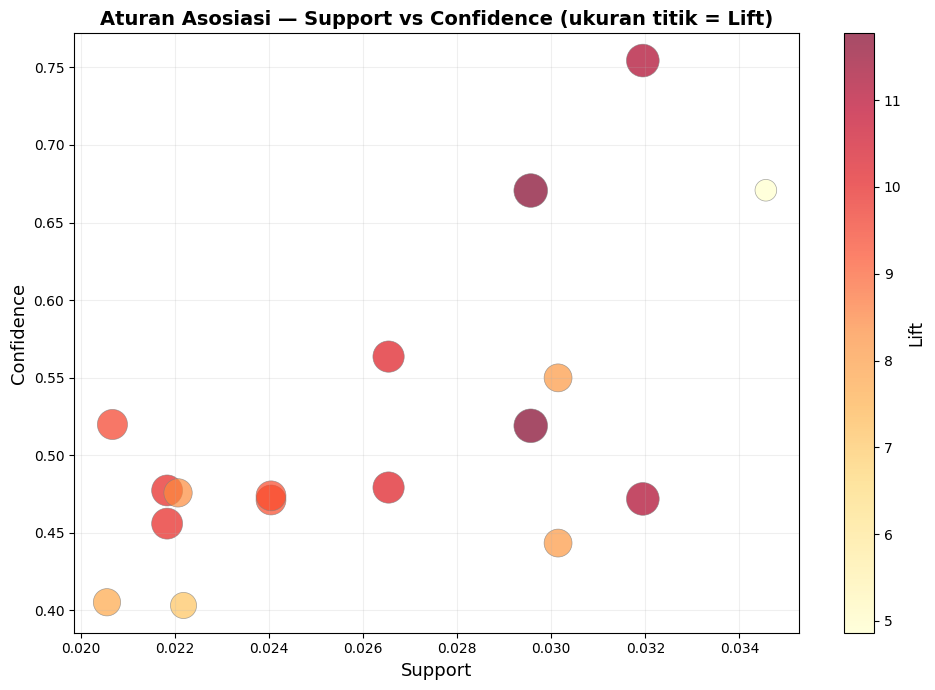

💡 Titik di kanan atas = aturan yang sering muncul DAN andal.
   Titik besar (Lift tinggi) = hubungan A→B sangat kuat, bukan kebetulan.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# ============================================================
# VISUALISASI: TOP 10 ATURAN BERDASARKAN LIFT
# ============================================================
# Scatter plot: Support vs Confidence, ukuran titik = Lift
# Semakin besar titik → Lift semakin tinggi → aturan semakin kuat
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Ambil top 50 aturan untuk visualisasi
top_rules = strong_rules.head(50)

scatter = ax.scatter(
    top_rules['support'],           # Sumbu X: Support
    top_rules['confidence'],        # Sumbu Y: Confidence
    s=top_rules['lift'] * 50,      # Ukuran titik proporsional terhadap Lift
    c=top_rules['lift'],           # Warna berdasarkan Lift
    cmap='YlOrRd',                  # Colormap: kuning-oranye-merah
    alpha=0.7,
    edgecolors='grey',
    linewidth=0.5
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', fontsize=12)

ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Aturan Asosiasi — Support vs Confidence (ukuran titik = Lift)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("💡 Titik di kanan atas = aturan yang sering muncul DAN andal.")
print("   Titik besar (Lift tinggi) = hubungan A→B sangat kuat, bukan kebetulan.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

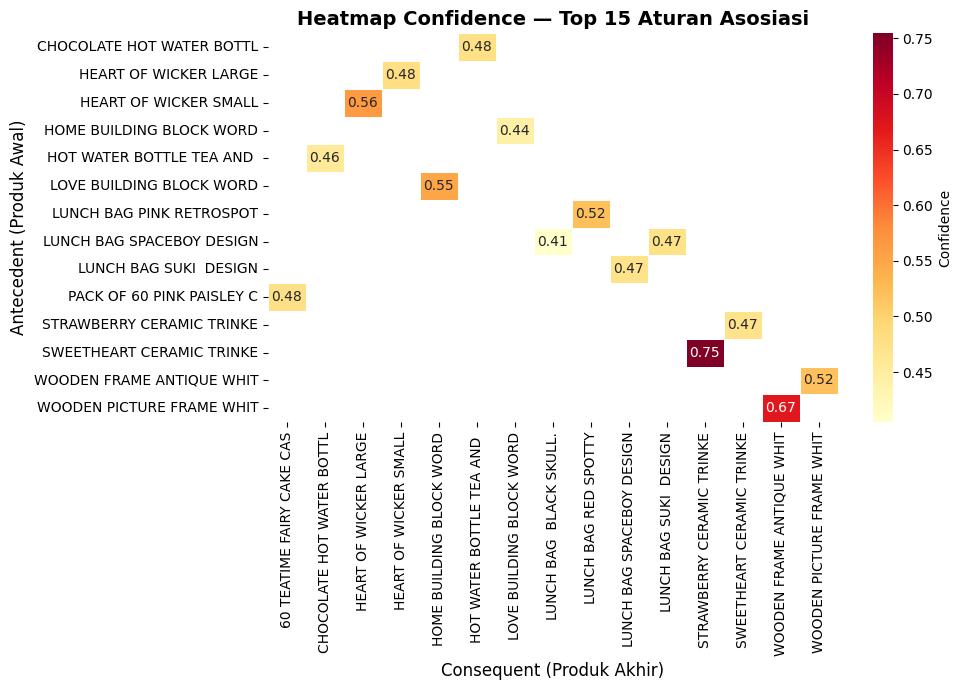

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


💡 Warna lebih gelap = confidence lebih tinggi.
   Artinya: jika pelanggan beli produk di sumbu Y, kemungkinan besar juga beli produk di sumbu X.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
# ============================================================
# VISUALISASI: HEATMAP CONFIDENCE TOP ATURAN
# ============================================================
# Heatmap menunjukkan confidence antara antecedent (sumbu Y) dan consequent (sumbu X)
# Warna lebih gelap = confidence lebih tinggi
# ============================================================

# Ambil top 15 aturan untuk heatmap
top15 = strong_rules.head(15).copy()

# Buat label singkat untuk antecedent dan consequent
top15['ant_label'] = top15['antecedents'].apply(lambda x: ', '.join(list(x))[:25])
top15['con_label'] = top15['consequents'].apply(lambda x: ', '.join(list(x))[:25])

# Buat pivot table untuk heatmap
heatmap_data = top15.pivot_table(
    index='ant_label',
    columns='con_label',
    values='confidence',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Confidence'})
ax.set_title('Heatmap Confidence — Top 15 Aturan Asosiasi', fontsize=14, fontweight='bold')
ax.set_xlabel('Consequent (Produk Akhir)', fontsize=12)
ax.set_ylabel('Antecedent (Produk Awal)', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 Warna lebih gelap = confidence lebih tinggi.")
print("   Artinya: jika pelanggan beli produk di sumbu Y, kemungkinan besar juga beli produk di sumbu X.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

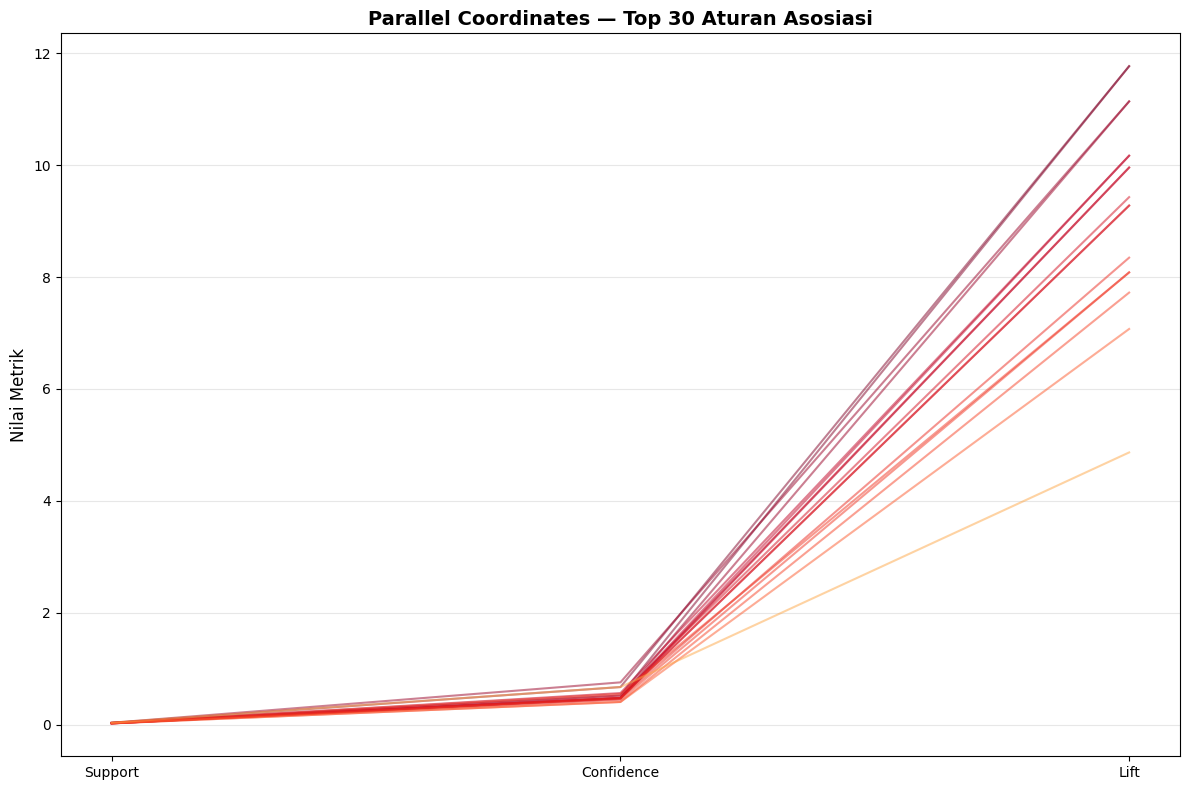

💡 Garis yang tinggi di ketiga sumbu = aturan yang sering muncul, andal, dan kuat hubungannya.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
# ============================================================
# VISUALISASI: PARALLEL COORDINATES — SUPPORT, CONFIDENCE, LIFT
# ============================================================
# Parallel coordinates menunjukkan hubungan ketiga metrik secara bersamaan
# Setiap garis = satu aturan asosiasi
# Garis yang naik dari Support ke Confidence ke Lift = aturan yang sangat kuat
# ============================================================

# Ambil top 30 aturan untuk visualisasi yang jelas
top30 = strong_rules.head(30).copy()

# Buat label untuk setiap aturan
top30['rule'] = top30['antecedents'].apply(lambda x: ', '.join(list(x))[:20]) + \
                ' → ' + \
                top30['consequents'].apply(lambda x: ', '.join(list(x))[:20])

fig, ax = plt.subplots(figsize=(12, 8))

# Plot parallel coordinates manual
for idx, row in top30.iterrows():
    ax.plot(['Support', 'Confidence', 'Lift'],
            [row['support'], row['confidence'], row['lift']],
            alpha=0.5, linewidth=1.5,
            color=plt.cm.YlOrRd(row['lift'] / top30['lift'].max()))

ax.set_ylabel('Nilai Metrik', fontsize=12)
ax.set_title('Parallel Coordinates — Top 30 Aturan Asosiasi', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("💡 Garis yang tinggi di ketiga sumbu = aturan yang sering muncul, andal, dan kuat hubungannya.")

In [11]:
# ============================================================
# INTERPRETASI HASIL & REKOMENDASI UNTUK UMKM MEBEL JEPARA
# ============================================================

print("=" * 70)
print("📊 INTERPRETASI HASIL ASSOCIATION RULES (APRIORI)")
print("=" * 70)
print()
print("1. JUMLAH ATURAN KUAT DITEMUKAN:", len(strong_rules))
print("   → Aturan dengan Lift>1, Confidence≥40%, Support≥2%")
print()
print("2. METRIK UTAMA:")
print("   - Support: seberapa sering aturan muncul di seluruh transaksi")
print("   - Confidence: dari pembeli A, berapa persen juga beli B")
print("   - Lift > 1: A dan B saling mendukung (bukan kebetulan)")
print()
print("3. REKOMENDASI UNTUK UMKM MEBEL JEPARA:")
print()
print("   a) BUNDLING PRODUK:")
print("      → Pasangan produk dengan Lift tinggi bisa dijadikan paket bundling")
print("      → Contoh: jika 'Meja Makan → Kursi Makan' punya Lift=5,")
print("        buat paket bundling 'Set Meja+Kursi Makan' dengan diskon khusus")
print()
print("   b) PENATAAN LAYOUT TOKO:")
print("      → Produk yang sering dibeli bersamaan ditempatkan berdekatan")
print("      → Memudahkan pelanggan menemukan produk pelengkap")
print()
print("   c) REKOMENDASI PRODUK (CROSS-SELLING):")
print("      → Saat pelanggan membeli produk A, tawarkan produk B")
print("      → Gunakan aturan dengan confidence tinggi sebagai dasar rekomendasi")
print()
print("   d) PROMOSI TARGETED:")
print("      → Berikan kupon diskon untuk produk B kepada pembeli produk A")
print("      → Fokus pada aturan dengan Lift > 3 (hubungan sangat kuat)")
print()
print("4. KELEBIHAN APRIORI:")
print("   - Mudah dipahami dan diinterpretasi")
print("   - Menghasilkan aturan yang actionable untuk bisnis")
print("   - Tidak memerlukan label/target (unsupervised)")
print()
print("5. KEKURANGAN APRIORI:")
print("   - Min_support terlalu rendah → terlalu banyak aturan (kurang bermakna)")
print("   - Min_support terlalu tinggi → aturan penting terlewat")
print("   - Komputasi berat untuk dataset sangat besar (itemset kombinasi eksponensial)")
print("   - Tidak menunjukkan kausalitas (hanya korelasi)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

📊 INTERPRETASI HASIL ASSOCIATION RULES (APRIORI)

1. JUMLAH ATURAN KUAT DITEMUKAN: 17
   → Aturan dengan Lift>1, Confidence≥40%, Support≥2%

2. METRIK UTAMA:
   - Support: seberapa sering aturan muncul di seluruh transaksi
   - Confidence: dari pembeli A, berapa persen juga beli B
   - Lift > 1: A dan B saling mendukung (bukan kebetulan)

3. REKOMENDASI UNTUK UMKM MEBEL JEPARA:

   a) BUNDLING PRODUK:
      → Pasangan produk dengan Lift tinggi bisa dijadikan paket bundling
      → Contoh: jika 'Meja Makan → Kursi Makan' punya Lift=5,
        buat paket bundling 'Set Meja+Kursi Makan' dengan diskon khusus

   b) PENATAAN LAYOUT TOKO:
      → Produk yang sering dibeli bersamaan ditempatkan berdekatan
      → Memudahkan pelanggan menemukan produk pelengkap

   c) REKOMENDASI PRODUK (CROSS-SELLING):
      → Saat pelanggan membeli produk A, tawarkan produk B
      → Gunakan aturan dengan confidence tinggi sebagai dasar rekomendasi

   d) PROMOSI TARGETED:
      → Berikan kupon diskon untuk 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag